In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

sys.path.insert(0, '/home/dominik/cc-workspace/coastal')
sys.path.insert(0, '/home/dominik/R-workspace/cecelia/inst')

%load_ext autoreload
%autoreload 2

from coastal import (
    # Data prep — single movie
    prepare_data_for_unet,
    normalize_and_project,
    VarianceMetricsConfig,
    compute_variance_metrics,
    # Data prep — multi-movie 4D
    prepare_data_for_unet_batch_4d,
    extract_sequences_from_volume,
    # Training
    train_test_split,
    train_test_split_per_movie,
    train_with_metrics,
    # Inference
    LearnedAffinityInference,
    TwoPassSegmentationInference,
    Inference3D,
    # Visualization & scoring
    visualize_frame_segmentation,
    plot_rgb_with_segmentation,
    score_segmentation,
    optimize_segmentation_cma,
)

print('✓ Imports successful')

✓ Imports successful


## Step 0: Load Image Data

Load from cecelia Zarr files. Update `base_dir` and `im_path` to match your dataset.

In [2]:
# config
import py.config_utils as cfg

In [3]:
import py.zarr_utils as zarr_utils
import py.ome_xml_utils as ome_xml_utils
from py.dim_utils import DimUtils

# load volumes
uIDs = ['xh9GFi', 'N0VlpP', 'qcN9Br', 'ENH3fS', 'uNTqPu']

# T cells
base_dir = '/home/dominik/cecelia/projects/R0YiZv/ANALYSIS'
# B cells
# base_dir = '/home/dominik/cecelia/projects/ISTgZF/ANALYSIS'

version_num = 1

volumes = dict()
pix_res = dict()

for i in uIDs:
    im_path = os.path.join(base_dir, f'0/{i}/ccidCorrected.zarr')
    # task_dir = os.path.join(base_dir, str(version_num), f'{i}')
    
    # Get image data
    im, _ = zarr_utils.open_as_zarr(im_path, as_dask=True)

    # Get OME-XML and dimension info
    omexml = ome_xml_utils.parse_meta(im_path)
    dim_utils = DimUtils(omexml, use_channel_axis=True)
    dim_utils.calc_image_dimensions(im[0].shape)
    
    volumes[i] = im
    pix_res[i] = dim_utils.im_physical_size('x')

<zarr.hierarchy.Group '/' read-only>
[61, 4, 16, 628, 625]
[625, 628, 16, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 16, 671, 632]
[632, 671, 16, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 15, 623, 624]
[624, 623, 15, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 22, 778, 930]
[930, 778, 22, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 16, 626, 627]
[627, 626, 16, 4, 61]
['X', 'Y', 'Z', 'C', 'T']


## Step 1 (Multi-Movie 4D): Extract Training Sequences

Extract 2D training sequences from a list of 4D volumes `[T, C, Z, Y, X]`.

- `n_sequences` z-slices are sampled **evenly across Z** per volume
- Each z-slice gets a **random start timepoint** → `seq_len` consecutive frames
- Optical flow is computed on the **mean-projected single channel**
- Variance metrics use the **full multi-channel** data
- Output format matches the existing `train_test_split_per_movie` + `train_with_metrics` pipeline

In [4]:
CH_INDICES = [0, 1, 2]  # first 3 channels; adjust if your 4th channel is DAPI / unwanted

# target_size=(H, W): resize all frames to a common spatial size.
# Required when volumes have different H×W and you want batch_size > 1.
# Set to None to keep original sizes — batch_size must then be 1 in training.
TARGET_SIZE = (512, 512)

all_frames, all_temporal, all_variance, all_frames_multi = prepare_data_for_unet_batch_4d(
    volumes,                 # dict {uid: [full_res, half_res, ...]} or list — both accepted
    n_sequences=3,           # z-slices per volume (evenly spaced)
    seq_len=20,              # frames per sequence
    ch_indices=CH_INDICES,
    temporal_scales=[1, 2, 4],
    cumulative_window=2,
    random_seed=42,
    target_size=TARGET_SIZE,
)

print(f"Sequences: {len(all_frames)}  ({len(volumes)} volumes × 3 sequences)")
print(f"Frames per sequence: {all_frames[0].shape}")
print(f"Temporal metrics: {len(all_temporal[0][0])}")
print(f"Variance metrics: {len(all_variance[0][0])}")


4D BATCH PREPARATION
  5 volumes × 3 sequences × 20 frames = 15 sequences

Volume 1/5: shape (61, 4, 16, 628, 625)


Frame metrics: 100%|████████████████████████████| 20/20 [00:01<00:00, 15.21it/s]


  Seq 1/3: z=0, t=3–22 | 14 temporal + 3 variance metrics


Frame metrics: 100%|████████████████████████████| 20/20 [00:01<00:00, 14.86it/s]


  Seq 2/3: z=7, t=32–51 | 14 temporal + 3 variance metrics


...

  Seq 1/3: z=0, t=21–40 | 14 temporal + 3 variance metrics


Frame metrics: 100%|████████████████████████████| 20/20 [00:01<00:00, 14.65it/s]


  Seq 2/3: z=7, t=38–57 | 14 temporal + 3 variance metrics


Frame metrics: 100%|████████████████████████████| 20/20 [00:01<00:00, 14.54it/s]


  Seq 3/3: z=15, t=9–28 | 14 temporal + 3 variance metrics

✓ 15 sequences ready for train_test_split_per_movie

Sequences: 15  (5 volumes × 3 sequences)
Frames per sequence: (20, 512, 512)
Temporal metrics: 14
Variance metrics: 3


In [5]:
# No train/test split — use all 300 frames for training
train_frames  = np.concatenate(all_frames, axis=0)           # [N_total, H, W]
train_temporal = [m for seq in all_temporal for m in seq]    # flat list of dicts
train_variance = [m for seq in all_variance for m in seq]    # flat list of dicts

print(f"Training frames:  {train_frames.shape}")
print(f"Temporal metrics: {len(train_temporal)}")
print(f"Variance metrics: {len(train_variance)}")

# Pick one sequence for visual inspection / parameter tuning after training
EVAL_SEQ_IDX = 0
eval_frames_maxproj = all_frames[EVAL_SEQ_IDX]       # [20, H, W]
eval_temporal       = all_temporal[EVAL_SEQ_IDX]     # list of 20 dicts
eval_variance       = all_variance[EVAL_SEQ_IDX]     # list of 20 dicts
eval_frames_multi   = all_frames_multi[EVAL_SEQ_IDX] # [20, C, H, W]

Training frames:  (300, 512, 512)
Temporal metrics: 300
Variance metrics: 300


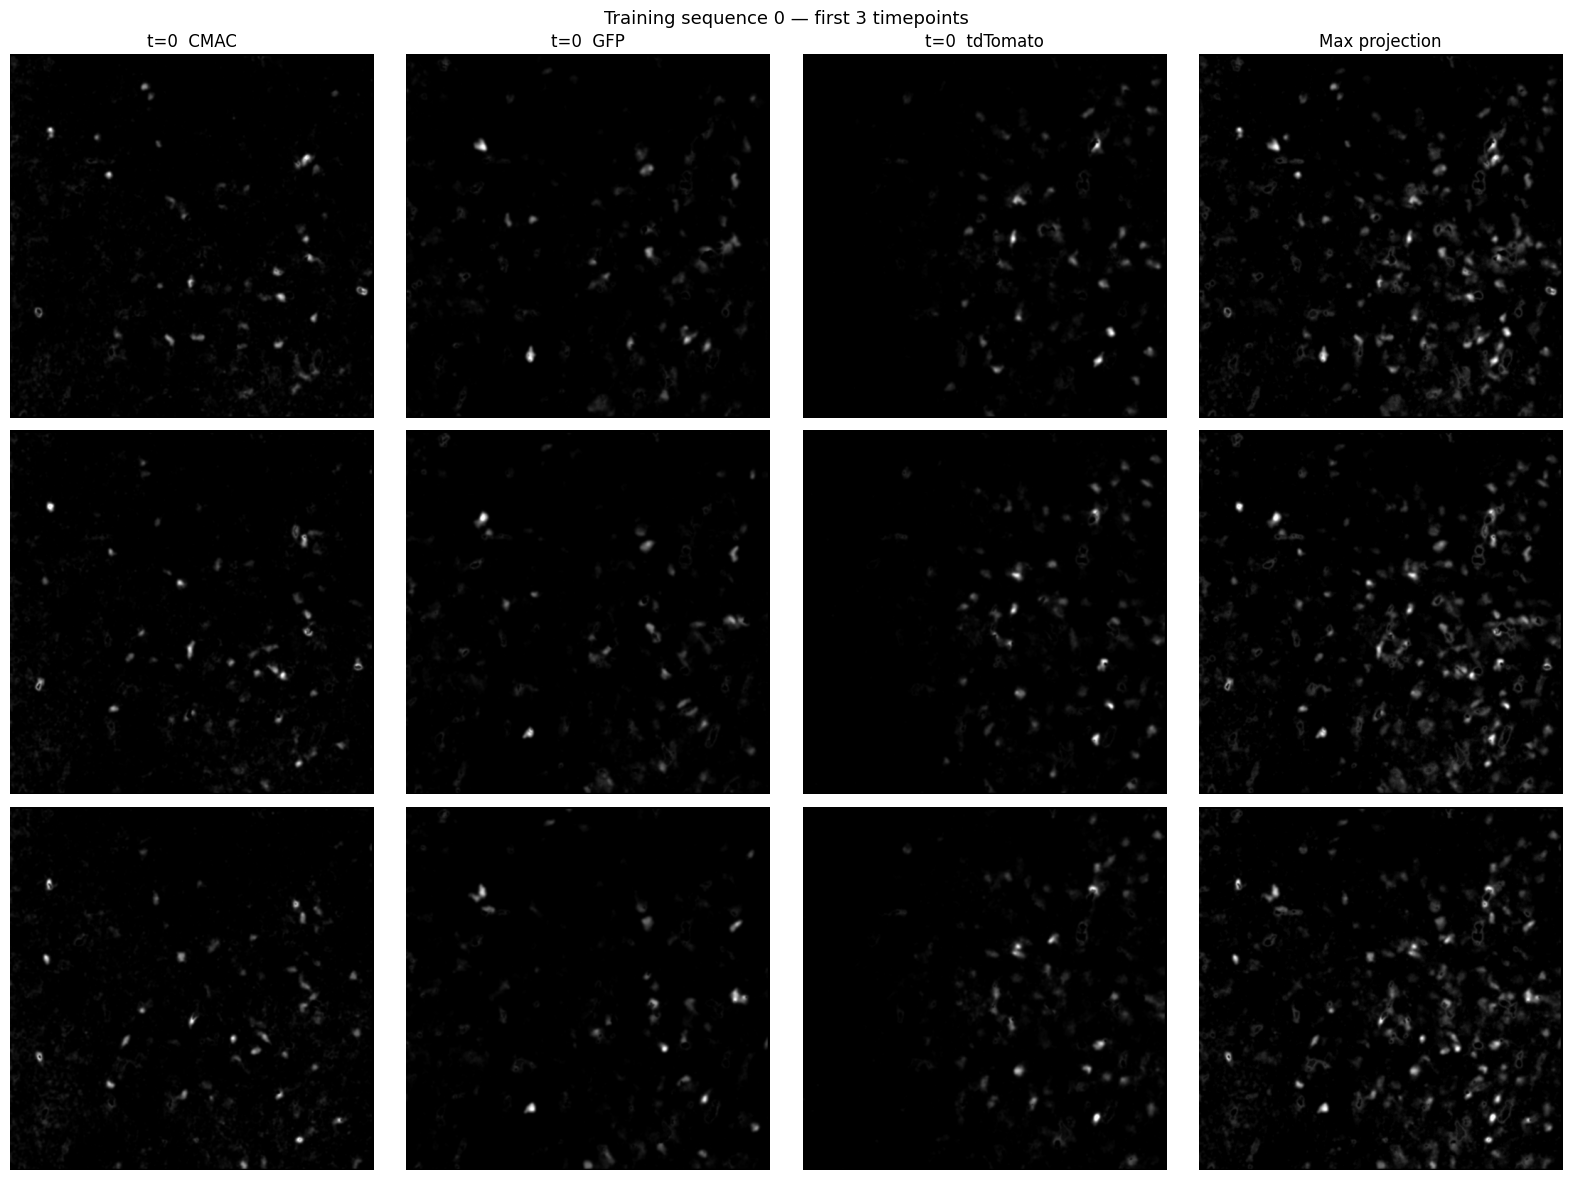

  Center 1: 2 frames, cumulative mag: min=0.000000, max=25.878889
  Center 0: 1 frames, cumulative mag: min=0.000000, max=45.220325
  Center 0: 1 frames, cumulative mag: min=0.000000, max=28.308958
  Center 1: 2 frames, cumulative mag: min=0.000000, max=33.372913
  Center 0: 1 frames, cumulative mag: min=0.000000, max=19.099697
  Center 0: 1 frames, cumulative mag: min=0.000000, max=0.000000
  Center 0: 1 frames, cumulative mag: min=0.000000, max=18.705084
  Center 2: 2 frames, cumulative mag: min=0.000000, max=25.143322
  Center 1: 2 frames, cumulative mag: min=0.000000, max=0.000000
  Center 2: 2 frames, cumulative mag: min=0.000000, max=0.000000
  Center 2: 2 frames, cumulative mag: min=0.000000, max=26.408840
  Center 0: 1 frames, cumulative mag: min=0.000000, max=24.142410
  Center 1: 2 frames, cumulative mag: min=0.000000, max=31.479439
  Center 0: 1 frames, cumulative mag: min=0.000000, max=15.922107
  Center 1: 2 frames, cumulative mag: min=0.000000, max=30.336256
  Center 1: 2

In [7]:
channel_names = ['CMAC', 'GFP', 'tdTomato']
n_t = 3  # timepoints to show

fig, axes = plt.subplots(n_t, 4, figsize=(16, 4 * n_t))
for t in range(n_t):
    for i, name in enumerate(channel_names):
        axes[t, i].imshow(eval_frames_multi[t, i], cmap='gray')
        axes[t, i].set_title(f't={t}  {name}' if t == 0 else '')
        axes[t, i].axis('off')
    axes[t, 3].imshow(eval_frames_maxproj[t], cmap='gray')
    axes[t, 3].set_title('Max projection' if t == 0 else '')
    axes[t, 3].axis('off')

plt.suptitle(f'Training sequence {EVAL_SEQ_IDX} — first {n_t} timepoints', fontsize=13)
plt.tight_layout()
plt.show()

## Step 2: Compute Temporal and Variance Metrics

- **Temporal metrics**: optical flow computed on max projection — model input at train and inference
- **Variance metrics**: cross-channel color statistics — model input at train (with channel dropout), zeroed at inference
  - `color_entropy`: how strongly one channel dominates locally (brightness-weighted)
  - `softmax_ch_0..N`: per-channel local softmax — directly encodes color identity per pixel
  - Channel dropout (`variance_dropout_p`) trains the model to work without them at inference

In [ ]:
frames_prep, flows, cum_flows, temporal_metrics = prepare_data_for_unet(
    frames_maxproj,
    temporal_scales=[1, 2, 4],
    cumulative_window=2,
)

print(f'Temporal metrics: {len(temporal_metrics[0])} per frame')
print(f'  keys: {sorted(temporal_metrics[0].keys())}')

In [ ]:
# Ablate: just pixel metrics, no spatial
cfg = VarianceMetricsConfig(pool_radius=1)
variance_metrics = compute_variance_metrics(frames_multi, cfg)

print(f'Variance metrics: {len(variance_metrics[0])} per frame')
print(f'  keys: {sorted(variance_metrics[0].keys())}')

In [ ]:
# Visualize variance metrics for a sample frame
# Shows how much signal vs noise is in each metric before committing to training.
frame_idx = 0
var_dict = variance_metrics[frame_idx]
var_keys = sorted(var_dict.keys())

channel_names = ['CMAC', 'GFP', 'tdTomato']
n_var = len(var_keys)
n_cols = 3
n_rows = 1 + (n_var + n_cols - 1) // n_cols  # 1 row for raw channels

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

# Row 0: raw channels for reference
for c in range(3):
    ax = axes[c]
    ax.imshow(frames_multi[frame_idx, c], cmap='gray')
    ax.set_title(f'Raw: {channel_names[c]}')
    ax.axis('off')

# Remaining rows: variance metrics
for i, key in enumerate(var_keys):
    ax = axes[n_cols + i]
    arr = var_dict[key]
    im = ax.imshow(arr, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'{key}\n[{arr.min():.2f}, {arr.max():.2f}]  std={arr.std():.3f}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for j in range(n_cols + n_var, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Variance metrics — frame {frame_idx}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Filter temporal metrics — remove keys that aren't useful for training.
# Edit this list to keep/drop any subset of the computed metrics.
keep_temporal = [
    'mag_1',
    'mag_2',
    'mag_4',
    'acceleration',
    'direction_stability',
    'cumulative_mag',
    'divergence',
    'vorticity',
    'strain',
    'edge_strength',
    'flow_structure_alignment',
    'normal_flow',
    'tangential_flow',
    'cell_boundary_likelihood',
]

n_before = len(temporal_metrics[0])
temporal_metrics = [{k: v for k, v in m.items() if k in keep_temporal}
                    for m in temporal_metrics]
n_after = len(temporal_metrics[0])
print(f'Temporal metrics: {n_before} → {n_after} keys')
print(f'Kept: {sorted(temporal_metrics[0].keys())}')

In [ ]:
# Visualize flow metrics for a sample frame
frame_idx = 10
metrics_dict = temporal_metrics[frame_idx]
metric_names = sorted(metrics_dict.keys())

# Filter to 2D metrics only
valid_metrics = [
    (name, metrics_dict[name]) 
    for name in metric_names 
    if isinstance(metrics_dict[name], np.ndarray) and metrics_dict[name].ndim == 2
]

if valid_metrics:
    n_metrics = len(valid_metrics)
    cols = 3
    rows = (n_metrics + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
    axes = axes.flatten()
    
    for idx, (name, metric_arr) in enumerate(valid_metrics):
        ax = axes[idx]
        im = ax.imshow(metric_arr, cmap='viridis')
        ax.set_title(f'{name}\n(min={metric_arr.min():.2f}, max={metric_arr.max():.2f})')
        ax.axis('off')
        plt.colorbar(im, ax=ax)
    
    for idx in range(n_metrics, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
n_frames = len(frames_maxproj)
n_train = int(n_frames * 0.8)
test_start_idx = n_train

train_frames, test_frames, train_temporal, test_temporal = train_test_split(
    frames_prep[:, np.newaxis, :, :],  # [T, 1, H, W] — float32 [0,1] from prepare_data_for_unet
    temporal_metrics,
    train_ratio=0.8,
    shuffle=False,
)

# Split variance metrics using same indices (no shuffle)
train_variance = variance_metrics[:n_train]
test_variance  = variance_metrics[n_train:]

# Define here so downstream cells always have a fresh copy
test_frames_maxproj = test_frames[:, 0, :, :]  # [N, H, W]

print(f'Train frames: {train_frames.shape}')
print(f'Test frames:  {test_frames.shape}  → maxproj: {test_frames_maxproj.shape}')
print(f'Test spans t={test_start_idx}..{n_frames - 1}')


## Step 3: Train UNet with Learned Embeddings

3-loss design:
- **IntensityLoss**: brightness / contrast / edge guidance
- **TemporalMetricsLoss**: contrastive on optical flow metrics
- **VarianceMetricsLoss**: windowed contrastive on color metrics (ground truth cell identity)

In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

model, history = train_with_metrics(
    train_frames,
    train_temporal,
    variance_metrics_norm=train_variance,
    num_epochs=120,
    batch_size=4,
    embedding_dim=64,
    intensity_weight=1.0,
    temporal_weight=2.0,
    variance_weight=4.0,
    variance_window_size=32,
    variance_dropout_p=0.2,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(history['total'],     'k-',  label='Total',    linewidth=2)
ax.plot(history['intensity'], 'b-',  label='Intensity', alpha=0.8)
ax.plot(history['temporal'],  'r-',  label='Temporal',  alpha=0.8)
ax.plot(history['variance'],  'g-',  label='Variance',  alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training losses')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Metric importance: ablation study on probability map
# Zero each metric channel one at a time, measure prob map change.
# Variance channels are zeroed at inference; only temporal channels are ablated.
frame_idx = 4
frame = train_frames[frame_idx, 0] if train_frames.ndim == 3 else train_frames[frame_idx].mean(axis=0)
t_metrics = train_temporal[frame_idx]
n_variance = len(train_variance[frame_idx]) if train_variance else 0

frame_norm = (frame - frame.mean()) / (frame.std() + 1e-5)
frame_tensor = torch.from_numpy(frame_norm).float().unsqueeze(0).unsqueeze(0)

metric_names = sorted(t_metrics.keys())
metric_tensors = [
    torch.from_numpy(t_metrics[k]).float() if isinstance(t_metrics[k], np.ndarray)
    else t_metrics[k].float()
    for k in metric_names
]
metrics_stacked = torch.stack(metric_tensors, dim=0).unsqueeze(0)

# Variance channels zeroed — this is the inference-time input distribution
H, W = frame_tensor.shape[-2:]
variance_zeros = torch.zeros(1, n_variance, H, W)
full_input = torch.cat([frame_tensor, metrics_stacked, variance_zeros], dim=1)

_device = next(model.parameters()).device
model.eval()

with torch.no_grad():
    prob_baseline = torch.sigmoid(model(full_input.to(_device))[0])[0, 0].cpu().numpy()

importances = []
prob_ablated_maps = []
for i, name in enumerate(metric_names):
    ablated = full_input.clone().to(_device)
    ablated[:, 1 + i, :, :] = 0.0
    with torch.no_grad():
        prob_abl = torch.sigmoid(model(ablated)[0])[0, 0].cpu().numpy()
    importances.append(np.abs(prob_baseline - prob_abl).mean())
    prob_ablated_maps.append(prob_abl)

# --- Bar chart ---
sorted_idx = np.argsort(importances)[::-1]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(metric_names)), [importances[i] for i in sorted_idx])
ax.set_xticks(range(len(metric_names)))
ax.set_xticklabels([metric_names[i] for i in sorted_idx], rotation=45, ha='right')
ax.set_ylabel('Mean |prob_full − prob_ablated|')
ax.set_title('Metric importance for probability map (channel ablation)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# --- Grid: baseline | ablated | diff for each metric ---
n_metrics = len(metric_names)
fig, axes = plt.subplots(n_metrics, 3, figsize=(12, 3.5 * n_metrics))
if n_metrics == 1:
    axes = axes[np.newaxis, :]

vmax_diff = max(np.abs(prob_baseline - m).max() for m in prob_ablated_maps) + 1e-5

for i, name in enumerate(metric_names):
    diff_map = prob_baseline - prob_ablated_maps[i]
    axes[i, 0].imshow(prob_baseline, cmap='hot', vmin=0, vmax=1)
    axes[i, 0].set_ylabel(name, fontsize=9)
    axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
    if i == 0:
        axes[i, 0].set_title('Baseline')

    axes[i, 1].imshow(prob_ablated_maps[i], cmap='hot', vmin=0, vmax=1)
    axes[i, 1].set_xticks([]); axes[i, 1].set_yticks([])
    if i == 0:
        axes[i, 1].set_title('Without metric')

    im = axes[i, 2].imshow(diff_map, cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff)
    axes[i, 2].set_title(f'mean|Δ|={importances[i]:.4f}' if i == 0 else f'{importances[i]:.4f}')
    axes[i, 2].set_xticks([]); axes[i, 2].set_yticks([])

plt.suptitle('Per-metric ablation (red = prob drops without metric, blue = prob rises)', fontsize=11)
plt.tight_layout()
plt.show()


## Step 4: Run Instance Segmentation Inference

Use two-pass strategy:
- **Pass 1**: Large seeds (32px), low affinity threshold → Find large cells
- **Pass 2**: Small seeds (8px), high affinity threshold → Find small fragments

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap
import torch

# --- pick a frame from the eval sequence ---
FRAME_IDX = 0
frame_hw = eval_frames_maxproj[FRAME_IDX]
t_metrics = eval_temporal[FRAME_IDX]
v_metrics = eval_variance[FRAME_IDX]

# multi-channel frame for dominant-channel coloring
frame_mc = eval_frames_multi[FRAME_IDX]    # [C, H, W]
C, H, W = frame_mc.shape
dominant_channel = frame_mc.argmax(axis=0) # [H, W]

# ── 1. Variance metric maps ──────────────────────────────────────────────────
show_keys = sorted(v_metrics.keys())
if show_keys:
    fig, axes = plt.subplots(1, len(show_keys), figsize=(4 * len(show_keys), 4))
    if len(show_keys) == 1:
        axes = [axes]
    for ax, k in zip(axes, show_keys):
        ax.imshow(v_metrics[k], cmap='viridis', vmin=0, vmax=1)
        ax.set_title(k); ax.axis('off')
    plt.suptitle('Variance metrics'); plt.tight_layout(); plt.show()

# ── 2. UMAP of embeddings colored by dominant channel ───────────────────────
frame_norm = (frame_hw - frame_hw.min()) / (frame_hw.max() - frame_hw.min() + 1e-5)
if frame_norm.ndim == 2:
    frame_t = torch.from_numpy(frame_norm).float().unsqueeze(0).unsqueeze(0)
else:
    frame_t = torch.from_numpy(frame_norm).float().unsqueeze(0)

metric_list = [torch.from_numpy(np.array(v)).float()
               for k, v in sorted(t_metrics.items())]
metrics_t = torch.stack(metric_list).unsqueeze(0)

n_variance = len(v_metrics)
variance_zeros = torch.zeros(1, n_variance, frame_t.shape[-2], frame_t.shape[-1])
inp = torch.cat([frame_t, metrics_t, variance_zeros], dim=1).to(next(model.parameters()).device)

with torch.no_grad():
    prob, emb = model(inp)
    prob_map = torch.sigmoid(prob)[0, 0].cpu().numpy()
    emb_np = emb[0].permute(1, 2, 0).cpu().numpy()  # [H, W, D]

mask = prob_map > 0.5
ys, xs = np.where(mask)
if len(ys) > 5000:
    idx = np.random.choice(len(ys), 5000, replace=False)
    ys, xs = ys[idx], xs[idx]

emb_flat = emb_np[ys, xs]
dom_flat = dominant_channel[ys, xs]

reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
emb_2d = reducer.fit_transform(emb_flat)

colors = ["red", "green", "blue", "orange"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for c in range(C):
    sel = dom_flat == c
    axes[0].scatter(emb_2d[sel, 0], emb_2d[sel, 1],
                    c=colors[c], s=2, alpha=0.3, label=f"ch{c}")
axes[0].set_title("UMAP of embeddings (colored by dominant channel)")
axes[0].legend(markerscale=5)
axes[1].imshow(dominant_channel, cmap="jet", interpolation="nearest")
axes[1].set_title("Dominant channel map"); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
  from coastal.optimize import score_segmentation

  eval_frames_mc = frames_multi[test_start_idx:][:5]
  eval_frames_seg = test_frames_maxproj[:5]
  eval_temporal_sub = test_temporal[:5]

  for label, kwargs in [
      ("strict",    dict(affinity_threshold=0.8, merge_affinity_threshold=0.8,
                         merge_max_distance=0.5, merge_contact_brightness_threshold=0.8,
                         prob_weight=0.0)),
      ("loose",     dict(affinity_threshold=0.2, merge_affinity_threshold=0.2,
                         merge_max_distance=3.0, merge_contact_brightness_threshold=0.2,
                         prob_weight=0.8)),
      ("current",   dict(affinity_threshold=0.6, merge_affinity_threshold=0.7,
                         merge_max_distance=1.0, merge_contact_brightness_threshold=0.7,
                         prob_weight=0.4)),
  ]:
      seg = LearnedAffinityInference(model=model, device='cuda',
          seed_size=12, embedding_blur_sigma=1.0, prob_threshold=0.5,
          min_component_size=12, max_iter=200, min_boundary_pixels=8, **kwargs)
      r = seg.predict_sequence(eval_frames_seg, eval_temporal_sub)
      s = score_segmentation(r, eval_frames_mc, verbose=True)
      print(f">>> {label}: {s:.4f}\n")


In [ ]:
from coastal.optimize import score_segmentation

for label, kwargs in [
    ("strict",    dict(affinity_threshold=0.8, merge_affinity_threshold=0.8,
                       merge_max_distance=0.5, merge_contact_brightness_threshold=0.8,
                       prob_weight=0.0)),
    ("loose",     dict(affinity_threshold=0.2, merge_affinity_threshold=0.2,
                       merge_max_distance=3.0, merge_contact_brightness_threshold=0.2,
                       prob_weight=0.8)),
    ("current",   dict(affinity_threshold=0.6, merge_affinity_threshold=0.7,
                       merge_max_distance=1.0, merge_contact_brightness_threshold=0.7,
                       prob_weight=0.4)),
]:
    seg = LearnedAffinityInference(model=model, device='cuda',
        seed_size=12, embedding_blur_sigma=1.0, prob_threshold=0.5,
        min_component_size=12, max_iter=200, min_boundary_pixels=8, **kwargs)
    r = seg.predict_sequence(eval_frames_maxproj, eval_temporal)
    s = score_segmentation(r, eval_frames_multi, verbose=True)
    print(f">>> {label}: {s:.4f}\n")

In [ ]:
from coastal.optimize import optimize_segmentation_cma, score_segmentation

best_params, history = optimize_segmentation_cma(
    model=model,
    frames=eval_frames_maxproj,
    frames_multi=eval_frames_multi,
    temporal_metrics=eval_temporal,
    x0=[0.5, 0.5, 1.0, 0.5, 0.5],
    sigma0=0.20,
    max_evals=40,
    n_frames=5,
    min_cell_size=100,
    purity_threshold=0.8,
    count_penalty_weight=0.005,
    fixed_params={
        'seed_size': 12,
        'embedding_blur_sigma': 1.0,
        'prob_threshold': 0.5,
        'min_component_size': 12,
        'max_iter': 200,
        'min_boundary_pixels': 8,
    },
    device='cuda',
)

segmentor = LearnedAffinityInference(model=model, device='cuda', **best_params)

In [ ]:
print(f'Running inference on eval sequence ({len(eval_frames_maxproj)} frames)...')
results = segmentor.predict_sequence(eval_frames_maxproj, eval_temporal)

n_cells_per_frame = [r['num_cells'] for r in results]
print(f'\n✓ Done — cells per frame: min={min(n_cells_per_frame)}, '
      f'max={max(n_cells_per_frame)}, mean={np.mean(n_cells_per_frame):.1f}')

In [ ]:
from coastal import plot_rgb_with_segmentation

plot_rgb_with_segmentation(
    frames_multi[test_start_idx:],   # [T, C, H, W]
    results,        # from predict_sequence
    ch_rgb=(0, 1, 2),          # which channels map to R, G, B
    min_cell_size=100,
    purity_threshold=0.8,
)

In [ ]:
from coastal import plot_rgb_with_segmentation

plot_rgb_with_segmentation(
    eval_frames_multi,     # [20, C, H, W]
    results,
    ch_rgb=(0, 1, 2),
    min_cell_size=100,
    purity_threshold=0.8,
)

In [ ]:
from coastal import score_segmentation

score_segmentation(results, eval_frames_multi, verbose=True)

In [ ]:
from coastal.viz import create_segmentation_movie

create_segmentation_movie(
    eval_frames_maxproj,
    results,
    output_path='/home/dominik/Downloads/TMP/segmentation_results.mp4',
)

In [ ]:
from coastal.viz import tune_inference_params_multi_frame, visualize_parameter_comparison

param_grid = {
    'seed_size_large': [32, 48],
    'affinity_threshold_large': [0.2, 0.8],
    'embedding_blur_sigma_large': [1.5],
    'merge_gap_iterations_large': [1, 2],
    'merge_affinity_threshold_large': [0.99],
    'merge_intensity_threshold_large': [0.2, 0.8],
    'seed_size_small': [8],
    'affinity_threshold_small': [0.8],
    'embedding_blur_sigma_small': [1.5],
    'merge_gap_iterations_small': [1],
    'merge_affinity_threshold_small': [0.9],
    'merge_intensity_threshold_small': [0],
    'prob_threshold': [0.1, 0.3],
    'max_iter': [200],
    'min_component_size': [10],
}

sweep_results = tune_inference_params_multi_frame(
    model,
    eval_frames_maxproj[4:5],
    eval_temporal[4:5],
    param_grid,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)

param_cols = [c for c in sweep_results.columns
              if c not in ['frame_idx', 'n_cells', 'instances']]
n_combos = len(sweep_results.groupby(param_cols))
print(f'✓ Tested {n_combos} parameter combinations')
print(f'Cell count range: {sweep_results["n_cells"].min():.0f} '
      f'– {sweep_results["n_cells"].max():.0f}')

In [ ]:
# Visualize top parameter combinations
visualize_parameter_comparison(sweep_results, test_frames_maxproj[4:5], max_combos=200)


## Step 5: 3D Temporal Segmentation

Segment a full 4D volume `[T, C, Z, Y, X]` in one call:

1. For each z-slice: compute temporal optical flow → run `predict_sequence`
2. For each timepoint: IOU-match instance labels across Z-planes

Returns `instances_4d [T, Z, H, W]` with consistent cell IDs across Z.

In [ ]:
inferencer_3d = Inference3D(
    model=model,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    **best_params,   # from CMA-ES cell above; or paste your own dict
)

# Select a volume to segment — first full-resolution image from the dict
vol_for_inference = next(iter(volumes.values()))[0]  # [T, C, Z, Y, X]

instances_4d, results_per_z = inferencer_3d.predict_temporal_volume(
    vol_for_inference,
    ch_indices=CH_INDICES,   # same channels used in training
    stitch_threshold=0.0,
)

print(f"Output: {instances_4d.shape}  (T, Z, H, W)")
print(f"Unique cells at t=0: {len(np.unique(instances_4d[0])) - 1}")

In [ ]:
# Visualize one timepoint: show each Z-slice with color-coded segmentation
T_VIZ = 0   # which timepoint to visualize
vol_t = np.asarray(vol_for_inference[T_VIZ])  # [C, Z, H, W]

Z = instances_4d.shape[1]
fig, axes = plt.subplots(2, Z, figsize=(3 * Z, 6))

for z in range(Z):
    # RGB composite from first 3 channels
    rgb = np.stack([vol_t[CH_INDICES[i], z] for i in range(min(3, len(CH_INDICES)))], axis=-1)
    rgb = (rgb / (rgb.max() + 1e-8) * 255).astype(np.uint8)
    axes[0, z].imshow(rgb)
    axes[0, z].set_title(f'Z={z}  RGB')
    axes[0, z].axis('off')

    inst = instances_4d[T_VIZ, z]
    axes[1, z].imshow(inst, cmap='tab20', interpolation='nearest')
    axes[1, z].set_title(f'{len(np.unique(inst)) - 1} cells')
    axes[1, z].axis('off')

plt.suptitle(f'4D segmentation — t={T_VIZ}', fontsize=13)
plt.tight_layout()
plt.show()